In [1]:
import yaml # type: ignore
import torch # type: ignore
import numpy as np # type: ignore
from dotmap import DotMap # type: ignore
from gym.spaces import Box # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Use matplotlib's tex rendering
import matplotlib # type: ignore
matplotlib.rcParams['text.usetex'] = True

from pud.algos.ddpg import GoalConditionedCritic
from pud.utils import set_global_seed, set_env_seed
from pud.visualizers.visualize import plot_agent_paths
from pud.algos.lagrange.drl_ddpg_lag import DRLDDPGLag
from pud.collectors.constrained_collector import ConstrainedCollector
from pud.envs.safe_pointenv.pb_sampler import load_pb_set, sample_pbs_by_agent
from pud.algos.policies import SearchPolicy, ConstrainedSearchPolicy, MultiAgentSearchPolicy, ConstrainedMultiAgentSearchPolicy
from pud.envs.safe_pointenv.safe_wrappers import SafeGoalConditionedPointBlendWrapper, SafeGoalConditionedPointQueueWrapper, SafeGoalConditionedPointWrapper, safe_env_load_fn

/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load the evaluation configuration

In [2]:
env_type = "CenterDot"
config_file = "models/" + env_type + "/config.yaml"
constrained_ckpt_file = "models/" + env_type + "/constrained_ckpt.pth"
unconstrained_ckpt_file = "models/" + env_type + "/unconstrained_ckpt.pth" 
illustration_pb_file = "pud/envs/safe_pointenv/illustration_set/CenterDot_resize_3_linear_r3_4pts.txt"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.agent.cost_limit = 1.5
config.replay_buffer.max_size = 1000

set_global_seed(config.seed)

#### Load the evaluation environment

In [3]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "SafeGoalConditionedPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointBlendWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointBlendWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_env_load_fn(
    config.env.toDict(),
    config.cost_function.toDict(),
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
)

set_env_seed(eval_env, config.seed + 2)

[INFO] skipping the reset in PointEnv.__init__ because setup is not ready yet
[INFO] PointEnv setup: 0.022780418395996094 s
[INFO] SafePointEnv setup: 0.0037755966186523438 s


/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


#### Load the inference agent

In [4]:
obs_dim = eval_env.observation_space['observation'].shape[0]  # type: ignore
goal_dim = obs_dim
state_dim = obs_dim + goal_dim
assert eval_env.action_space.shape is not None
action_dim = eval_env.action_space.shape[0]
assert isinstance(eval_env.action_space, Box)
max_action = float(eval_env.action_space.high[0])
print(f'Obs dim: {obs_dim},\n'
      f'Goal dim: {goal_dim},\n'
      f'State dim: {state_dim},\n'
      f'Action dim: {action_dim},\n'
      f'Max action: {max_action}')

agent = DRLDDPGLag(
        state_dim,  # Concatenating obs and goal
        action_dim,
        max_action,
        CriticCls=GoalConditionedCritic,
        device=torch.device(config.device),
        **config.agent,
    )

agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

Obs dim: 2,
Goal dim: 2,
State dim: 4,
Action dim: 2,
Max action: 1.0


DRLDDPGLag(
  (actor): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): GoalConditionedActor(
    (l1): Linear(in_features=4, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, bias=True)
        (l3): Linear(in_features=256, out_features=20, bias=True)
      )
    )
  )
  (critic_target): EnsembledCritic(
    (critics): ModuleList(
      (0-2): 3 x GoalConditionedCritic(
        (l1): Linear(in_features=4, out_features=256, bias=True)
        (l2): Linear(in_features=258, out_features=256, b

#### Sample a replay buffer to form our search graph

In [5]:
rb_vec = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size)

agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()
unconstrained_pdist = agent.get_pairwise_dist(rb_vec, aggregate=None)  # type: ignore
unconstrained_pcost = agent.get_pairwise_cost(rb_vec, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file))
constrained_pdist = agent.get_pairwise_dist(rb_vec, aggregate=None)  # type: ignore

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file))

#### Sample (start, goal) problems for the agent

In [6]:
if len(illustration_pb_file) > 0:
    problems = load_pb_set(file_path=illustration_pb_file, env=eval_env, agent=agent)  # type: ignore
else:
    problems = sample_pbs_by_agent(
        K=10,
        min_dist=0,
        agent=agent,  # type: ignore
        env=eval_env,  # type: ignore
        target_val=10,
        num_states=100,
        ensemble_agg="mean",
        use_uncertainty=False,
        max_dist=eval_env.max_goal_dist,  # type: ignore
    )
    assert len(problems) > 0

eval_env.set_use_q(True)  # type: ignore
eval_env.set_prob_constraint(1.0)  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

## Single-Agent Comparisons

### Unconstrained Low-Level Policy

In [7]:
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectory(agent, eval_env)

### Unconstrained Low-Level Policy with Graph Search

In [8]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

search_policy = SearchPolicy(agent, rb_vec, pdist=unconstrained_pdist, open_loop=True, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectory(search_policy, eval_env)

/scratch/Work/Multi_Agent_Research/Hierarchical_Constrained_SORB/clean_code/cc-sorb-rev/pud/algos/lagrange/drl_ddpg_lag.py:117: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  observation=torch.FloatTensor(state["observation"]),


### Constrained Low-Level Policy

In [9]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectory(agent, eval_env)

### Constrained Low-Level Policy with Graph Search

In [10]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

constrained_search_policy = ConstrainedSearchPolicy(agent, rb_vec, pdist=constrained_pdist, pcost=unconstrained_pcost, open_loop=True, no_waypoint_hopping=True, max_cost_limit=config.agent.cost_limit, ckpts={"unconstrained" : unconstrained_ckpt_file, "constrained" : constrained_ckpt_file})
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectory(constrained_search_policy, eval_env)

#### Plot the single-agent comparison

In [11]:
unconstrained_observations = np.array(unconstrained_observations)
unconstrained_search_observations = np.array(unconstrained_search_observations)
constrained_observations = np.array(constrained_observations)
constrained_search_observations = np.array(constrained_search_observations)

unconstrained_search_waypoints = np.array(unconstrained_search_waypoints)
constrained_search_waypoints = np.array(constrained_search_waypoints)

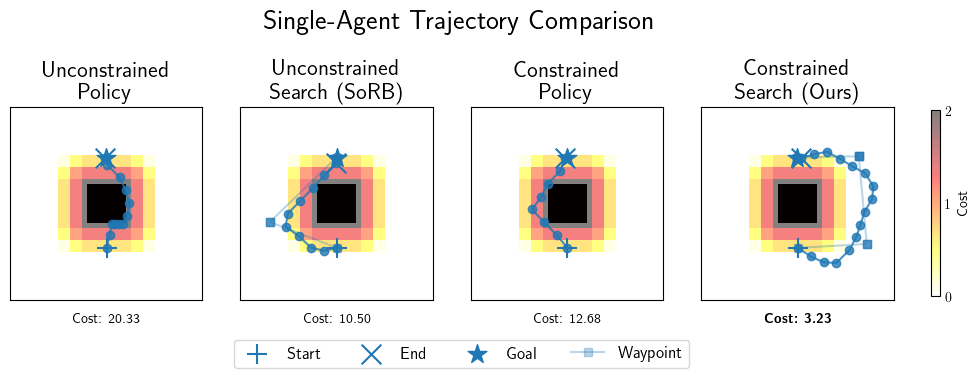

In [12]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

axs[0] = plot_agent_paths(0, start, goal, unconstrained_observations, "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs[0].text(0.5, -0.1, f"Cost: {unconstrained_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, weight='bold')

axs[1] = plot_agent_paths(0, start, goal, unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[1], wps=unconstrained_search_waypoints, use_agent_id=False)
axs[1].text(0.5, -0.1, f"Cost: {unconstrained_search_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[1].transAxes, weight='bold')

axs[2] = plot_agent_paths(0, start, goal, constrained_observations, "Constrained\nPolicy", axs[2], use_agent_id=False)
axs[2].text(0.5, -0.1, f"Cost: {constrained_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[2].transAxes, weight='bold')

axs[3] = plot_agent_paths(0, start, goal, constrained_search_observations, "Constrained\nSearch (Ours)", axs[3], wps=constrained_search_waypoints, use_agent_id=False)
axs[3].text(0.5, -0.1, rf"\textbf{{Cost: {constrained_search_records['cumulative_costs']:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[3].transAxes, weight='bold')

cbar.set_label("Cost")
plt.legend(loc="lower center", bbox_to_anchor=(-1.25, -0.4), ncol=4, fontsize=12)
_ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=20)
# plt.savefig("pud/plots/figures/paper/single_agent_pointenv_comparison.svg", bbox_inches="tight")

## Multi-Agent Comparisons

### Unconstrained Low-Level Policy

In [13]:
n_agents = 4
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents)

### Unconstrained Low-Level Policy with Graph Search

In [14]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

ma_search_policy = MultiAgentSearchPolicy(agent, rb_vec, n_agents, pdist=unconstrained_pdist, open_loop=True, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectories(ma_search_policy, eval_env, n_agents)

### Constrained Low-Level Policy

In [15]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore
start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents)

### Constrained Low-Level Policy with Graph Search

In [16]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=problems.copy())  # type: ignore

constrained_ma_search_policy = ConstrainedMultiAgentSearchPolicy(agent, rb_vec, n_agents, pdist=constrained_pdist, pcost=unconstrained_pcost, open_loop=True, no_waypoint_hopping=True, max_cost_limit=config.agent.cost_limit, ckpts={"unconstrained" : unconstrained_ckpt_file, "constrained" : constrained_ckpt_file})
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(constrained_ma_search_policy, eval_env, n_agents)

#### Plot the multi-agent comparison

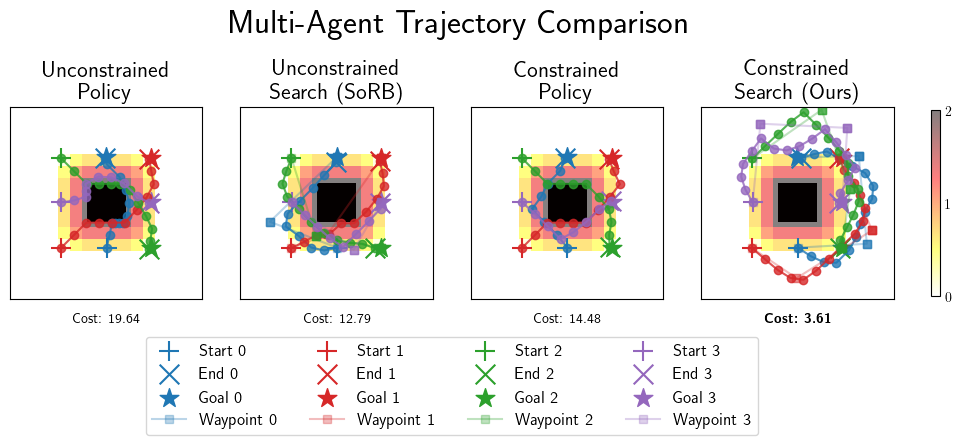

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.5, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

unconstrained_cc = max([record["cumulative_costs"] for record in unconstrained_records])
unconstrained_search_cc = max([record["cumulative_costs"] for record in unconstrained_search_records])
constrained_cc = max([record["cumulative_costs"] for record in constrained_records])
constrained_search_cc = max([record["cumulative_costs"] for record in constrained_search_records])
for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[0] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[0])
    axs[1] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[1], wps=agent_unconstrained_search_waypoints)
    axs[2] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[2])
    axs[3] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch (Ours)", axs[3], wps=agent_constrained_search_waypoints)

axs[0].text(0.5, -0.1, f"Cost: {unconstrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, weight='bold')
axs[1].text(0.5, -0.1, f"Cost: {unconstrained_search_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[1].transAxes, weight='bold')
axs[2].text(0.5, -0.1, f"Cost: {constrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[2].transAxes, weight='bold')
axs[3].text(0.5, -0.1, rf"\textbf{{Cost: {constrained_search_cc:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[3].transAxes, weight='bold')

plt.legend(loc="lower center", bbox_to_anchor=(-1.3, -0.75), ncol=4, fontsize=12)
_ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
# plt.savefig("pud/plots/figures/paper/multi_agent_pointenv_comparison.svg", bbox_inches="tight")

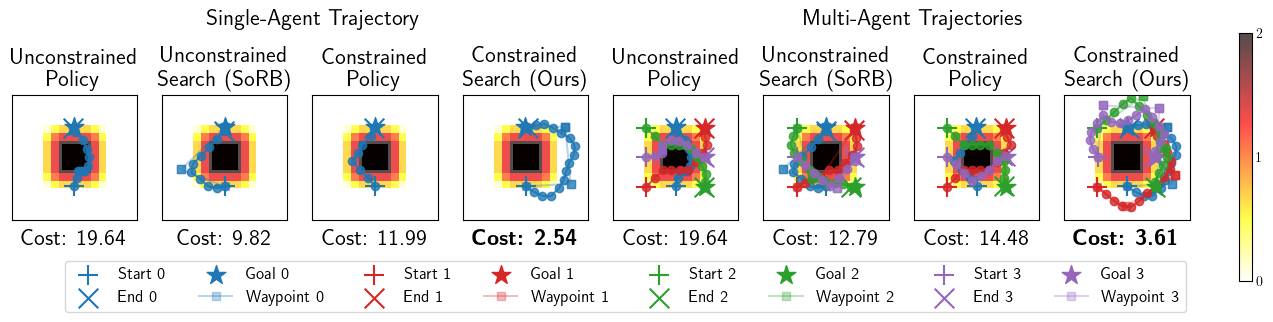

In [18]:
fig, axs = plt.subplots(1, 8, figsize=(16, 4))

for ax in axs:
    ax.imshow(eval_env.get_map(), cmap="binary", interpolation="nearest", alpha=1.0, extent=[0, 1, 0, 1])
    cmap = ax.imshow(eval_env.get_cost_map(), cmap="hot_r", interpolation="nearest", alpha=0.7, extent=[0, 1, 0, 1])
    ax.set_xticks([])
    ax.set_yticks([])

cbar = plt.colorbar(cmap, ax=axs, orientation="vertical", fraction=0.01, pad=0.04)
cbar.ax.tick_params(size=0)
cbar.set_ticks([0, 1, 2])

unconstrained_cc = max([record["cumulative_costs"] for record in unconstrained_records])
unconstrained_search_cc = max([record["cumulative_costs"] for record in unconstrained_search_records])
constrained_cc = max([record["cumulative_costs"] for record in constrained_records])
constrained_search_cc = max([record["cumulative_costs"] for record in constrained_search_records])

single_agent = 0
axs[0] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(unconstrained_observations[single_agent]), "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs[1] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(unconstrained_search_observations[single_agent]), "Unconstrained\nSearch (SoRB)", axs[1], wps=np.array(unconstrained_search_waypoints[single_agent]), use_agent_id=False)
axs[2] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(constrained_observations[single_agent]), "Constrained\nPolicy", axs[2], use_agent_id=False)
axs[3] = plot_agent_paths(single_agent, start[single_agent], goal[single_agent], np.array(constrained_search_observations[single_agent]), "Constrained\nSearch (Ours)", axs[3], wps=np.array(constrained_search_waypoints[single_agent]), use_agent_id=False)
axs[0].text(0.5, -0.15, f"Cost: {unconstrained_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, weight='bold', fontsize=16)
axs[1].text(0.5, -0.15, f"Cost: {unconstrained_search_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[1].transAxes, weight='bold', fontsize=16)
axs[2].text(0.5, -0.15, f"Cost: {constrained_records[single_agent]['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[2].transAxes, weight='bold', fontsize=16)
axs[3].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_records[single_agent]['cumulative_costs']:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[3].transAxes, weight='bold', fontsize=16)

for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[4] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[4])
    axs[5] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[5], wps=agent_unconstrained_search_waypoints)
    axs[6] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[6])
    axs[7] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch (Ours)", axs[7], wps=agent_constrained_search_waypoints)

axs[4].text(0.5, -0.15, f"Cost: {unconstrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[4].transAxes, weight='bold', fontsize=16)
axs[5].text(0.5, -0.15, f"Cost: {unconstrained_search_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[5].transAxes, weight='bold', fontsize=16)
axs[6].text(0.5, -0.15, f"Cost: {constrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs[6].transAxes, weight='bold', fontsize=16)
axs[7].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_cc:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs[7].transAxes, weight='bold', fontsize=16)

plt.legend(loc="lower center", bbox_to_anchor=(-3.5, -0.8), ncol=8, fontsize=12)
plt.text(2.4, 1.6, "Single-Agent Trajectory", horizontalalignment="center", verticalalignment="center", transform=axs[0].transAxes, fontsize=16)
plt.text(2.4, 1.6, "Multi-Agent Trajectories", horizontalalignment="center", verticalalignment="center", transform=axs[4].transAxes, fontsize=16)
# _ = plt.suptitle("Trajectory Comparisons", fontsize=24)
plt.savefig("pud/plots/figures/paper/pointenv_comparison_together.svg", bbox_inches="tight")